# Dynamic Pricing Algorithm Development
## Fitness Class Revenue Optimization

In [12]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [13]:
# =========================================================
# LOAD CLEANED DATASET
# =========================================================

df = pd.read_csv('/content/cleaned_preprocessed_dataset_Tejaswini Yeluduti.csv')

print("Dataset Loaded Successfully")

display(df.head())

Dataset Loaded Successfully


,activity_site_id,activity_description,booking_end_datetime,booking_start_time,max_bookees,number_booked,price_inr,year,month,day,day_name
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,14:45:00,25,12,499.0,2018,4,8,Sunday
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,14:45:00,25,15,499.0,2018,4,15,Sunday
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,14:45:00,25,14,499.0,2018,4,22,Sunday
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,14:45:00,25,9,499.0,2018,4,29,Sunday
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,14:45:00,25,7,499.0,2018,5,6,Sunday


In [14]:
# =========================================================
# DATETIME CONVERSION & FEATURE ENGINEERING
# =========================================================

df['booking_end_datetime'] = pd.to_datetime(
    df['booking_end_datetime']
)

df['year'] = df['booking_end_datetime'].dt.year
df['month'] = df['booking_end_datetime'].dt.month
df['day'] = df['booking_end_datetime'].dt.day
df['day_name'] = df['booking_end_datetime'].dt.day_name()

print("Date Features Created Successfully")

Date Features Created Successfully


In [15]:
# =========================================================
# CREATE OCCUPANCY RATE
# =========================================================

# Convert numeric columns

df['max_bookees'] = pd.to_numeric(
    df['max_bookees'],
    errors='coerce'
)

df['number_booked'] = pd.to_numeric(
    df['number_booked'],
    errors='coerce'
)

df['price_inr'] = pd.to_numeric(
    df['price_inr'],
    errors='coerce'
)

# Remove null values

df.dropna(inplace=True)

# Create occupancy rate

df['occupancy_rate'] = (
    df['number_booked'] /
    df['max_bookees']
) * 100

display(
    df[
        [
            'number_booked',
            'max_bookees',
            'occupancy_rate'
        ]
    ].head()
)

,number_booked,max_bookees,occupancy_rate
0,12,25,48.0
1,15,25,60.0
2,14,25,56.0
3,9,25,36.0
4,7,25,28.0


In [16]:
# =========================================================
# DEFINE DYNAMIC PRICING RULES
# =========================================================

def dynamic_price(row):

    base_price = row['price_inr']

    occupancy = row['occupancy_rate']

    # High demand
    if occupancy >= 80:
        return base_price * 1.20

    # Medium demand
    elif occupancy >= 50:
        return base_price * 1.10

    # Low demand
    else:
        return base_price * 0.90

In [17]:
# =========================================================
# APPLY DYNAMIC PRICING
# =========================================================

df['dynamic_price'] = df.apply(
    dynamic_price,
    axis=1
)

display(
    df[
        [
            'price_inr',
            'dynamic_price',
            'occupancy_rate'
        ]
    ].head()
)

,price_inr,dynamic_price,occupancy_rate
0,499.0,449.1,48.0
1,499.0,548.9,60.0
2,499.0,548.9,56.0
3,499.0,449.1,36.0
4,499.0,449.1,28.0


In [18]:
# =========================================================
# REVENUE COMPARISON
# =========================================================

df['original_revenue'] = (
    df['price_inr'] *
    df['number_booked']
)

df['dynamic_revenue'] = (
    df['dynamic_price'] *
    df['number_booked']
)

print("Original Revenue:")
print(df['original_revenue'].sum())

print("\nDynamic Pricing Revenue:")
print(df['dynamic_revenue'].sum())

Original Revenue:
99352395.0

Dynamic Pricing Revenue:
107212719.30000001


In [19]:
# =========================================================
# REVENUE IMPROVEMENT
# =========================================================

improvement = (
    (
        df['dynamic_revenue'].sum()
        -
        df['original_revenue'].sum()
    )
    /
    df['original_revenue'].sum()
) * 100

print("Revenue Improvement Percentage:")

print(round(improvement, 2), "%")

Revenue Improvement Percentage:
7.91 %


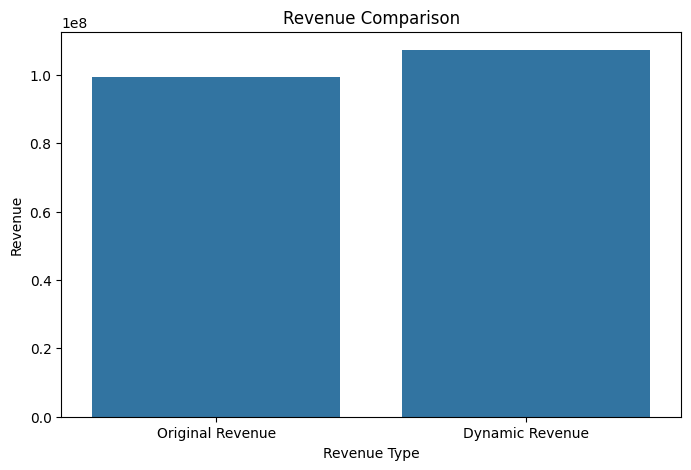

In [20]:
# =========================================================
# VISUALIZE REVENUE COMPARISON
# =========================================================

revenue_data = pd.DataFrame({

    'Revenue Type': [
        'Original Revenue',
        'Dynamic Revenue'
    ],

    'Revenue': [
        df['original_revenue'].sum(),
        df['dynamic_revenue'].sum()
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    x='Revenue Type',
    y='Revenue',
    data=revenue_data
)

plt.title('Revenue Comparison')

plt.show()

In [21]:
# =========================================================
# HIGH DEMAND PRICING ANALYSIS
# =========================================================

high_demand = df[
    df['occupancy_rate'] >= 80
]

display(
    high_demand[
        [
            'activity_description',
            'occupancy_rate',
            'price_inr',
            'dynamic_price'
        ]
    ].head()
)

,activity_description,occupancy_rate,price_inr,dynamic_price
35,20:20:20 10-11 Am,91.428571,499.0,598.8
40,20:20:20 10-11 Am,85.714286,499.0,598.8
43,20:20:20 10-11 Am,80.000000,499.0,598.8
47,20:20:20 10.00-11.00am,82.857143,499.0,598.8
50,20:20:20 10.00-11.00am,82.857143,499.0,598.8


# Business Recommendations

## High-Demand Classes
- Apply premium pricing during high occupancy periods.
- Increase pricing gradually for consistently popular classes.

## Low-Demand Periods
- Offer promotional pricing and discounts.
- Introduce loyalty packages or bundled offers.

## Forecast-Based Pricing
- Use demand forecasting models to adjust prices proactively.

## Operational Benefits
- Improve class utilization
- Maximize revenue per session
- Optimize customer demand management

# Key Insights

- Occupancy-based pricing improves revenue potential.
- Dynamic pricing allows flexible response to demand changes.
- High-demand classes support premium pricing strategies.
- Revenue optimization can be achieved without increasing class capacity.

# Conclusion

A dynamic pricing algorithm was successfully developed using:
- occupancy rates
- booking demand
- pricing behavior

The simulation demonstrated the potential for:
- higher revenue generation
- improved pricing efficiency
- better demand management

This solution provides a foundation for real-time pricing optimization in fitness class operations.